# AN2DL - Homework 1

## 1 - Libraries and Dataset Import


In [1]:
#%pip install tensorflow==2.17 keras==3.4.1
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

import os 
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress most logs
#os.environ["CUDA_VISIBLE_DEVICES"]="0"

import tensorflow as tf
import keras as tfk
import keras_cv
from keras import layers as kl
from keras_cv import layers as kcvl
from keras import mixed_precision

#mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(True)  # Enable XLA

print("GPUs Available: ", tf.config.list_physical_devices('GPU'))
print(f"TensorFlow version {tf.__version__}")

np.random.seed(42)
tf.random.set_seed(42)

/home/teo/Desktop/LabANN/venvANNUbu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version 2.17.0


I0000 00:00:1731581268.984626  106538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731581269.018426  106538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731581269.022070  106538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [2]:
data = np.load('training_set.npz')

X = data['images']
y = data['labels']
print(X.shape, y.shape)

(13759, 96, 96, 3) (13759, 1)


## 2 - Check for missing, duplicate values and class distribution

In [3]:
missing_targets = np.isnan(y.flatten()).any()

if not missing_targets :
    print("There are no missing or NaN values in the target vector.")

There are no missing or NaN values in the target vector.


In [4]:
# Duplicates count and removal
reshaped_X = X.reshape(X.shape[0], -1) # Reshape each image to a 1D vector and stack them for comparison

unique_X, unique_indices = np.unique(reshaped_X, axis=0, return_index=True) # Find unique images and their indices

# Select unique images and labels
X_unique = X[unique_indices]
y_unique = y[unique_indices]

print(f'Labels reduced from {len(y)} to {len(y_unique)}')
# (should output a reduction from 13759 to 11953)

Labels reduced from 13759 to 11953


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Basophil'),
  Text(1, 0, 'Eosinophil'),
  Text(2, 0, 'Erythroblast'),
  Text(3, 0, 'Immature granulocytes'),
  Text(4, 0, 'Lymphocyte'),
  Text(5, 0, 'Monocyte'),
  Text(6, 0, 'Neutrophil'),
  Text(7, 0, 'Platelet')])

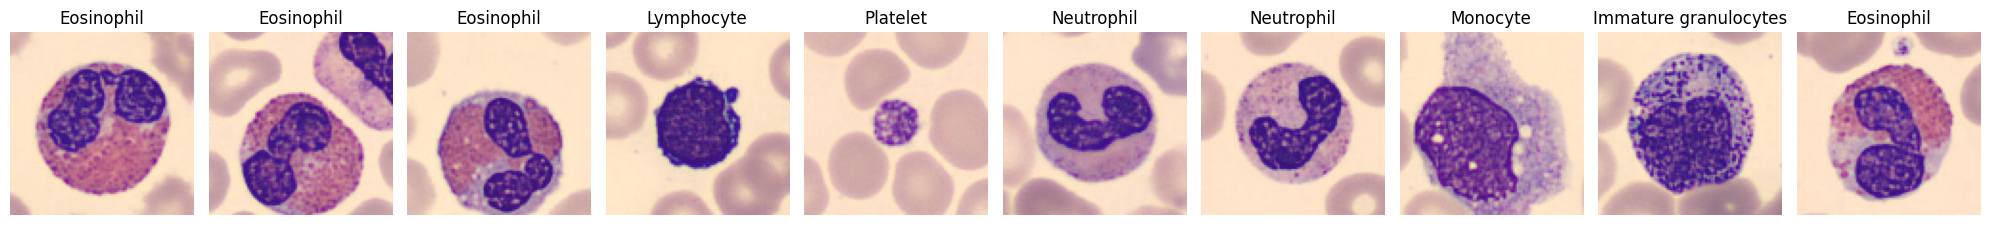

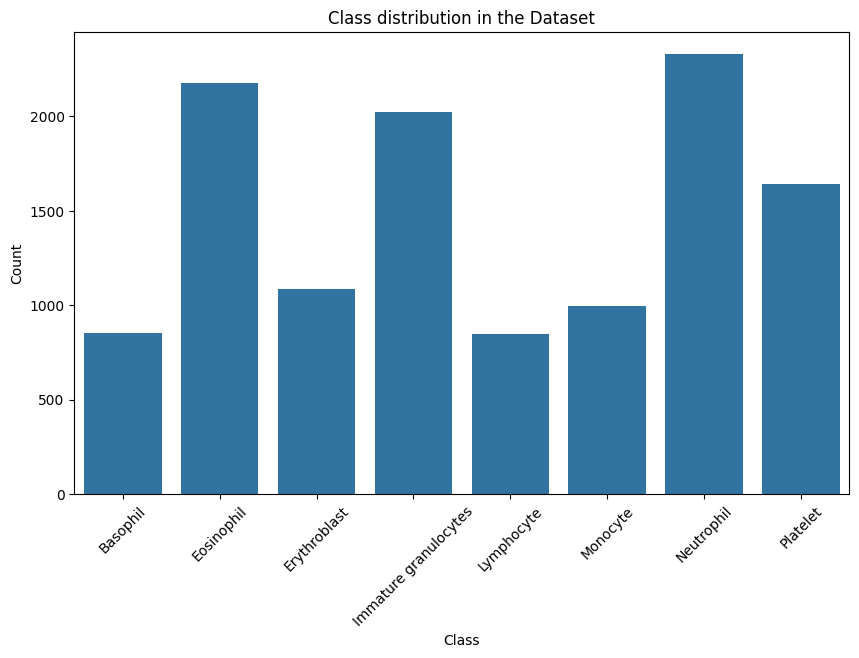

In [5]:
X = X_unique
y = y_unique

# Define a mapping of labels to their corresponding digit names
labels = {0:'Basophil', 1:'Eosinophil', 2:'Erythroblast', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelet'}

# Save unique labels
unique_labels = list(labels.values())

# Display a sample of images from the training-validation dataset
num_img = 10
random_indices = random.sample(range(len(X)), num_img)

fig, axes = plt.subplots(1, num_img, figsize=(20, 20))

# Iterate through the selected number of images
for i, idx in enumerate(random_indices):
    ax = axes[i % num_img]
    ax.imshow(np.squeeze(X[idx]), vmin=0., vmax=1.)
    ax.set_title(f'{labels[y[idx][0]]}')
    ax.axis('off')

# Adjust layout and display the images
plt.tight_layout()
#plt.show()

labels_list, counts = np.unique(y.flatten(), return_counts=True)
classes = [labels[label] for label in labels_list]
df = pd.DataFrame({'Class': classes, 'Count': counts})

# Plot the barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=classes, y=counts)
plt.title('Class distribution in the Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Adjust rotation for readability if needed
#plt.show()

In [6]:
'''
class_counts = pd.Series(y.flatten()).value_counts()

imbalance_ratio = class_counts.max() / class_counts.min()
print("Imbalance Ratio:", imbalance_ratio) # Between 1.5 and 4 considered moderately imbalanced

proportions = class_counts / class_counts.sum()
gini_index = 1 - sum(proportions ** 2)
print("Gini Index:", gini_index) # Between 0.1 and 0.25 considered moderately imbalanced
'''

'\nclass_counts = pd.Series(y.flatten()).value_counts()\n\nimbalance_ratio = class_counts.max() / class_counts.min()\nprint("Imbalance Ratio:", imbalance_ratio) # Between 1.5 and 4 considered moderately imbalanced\n\nproportions = class_counts / class_counts.sum()\ngini_index = 1 - sum(proportions ** 2)\nprint("Gini Index:", gini_index) # Between 0.1 and 0.25 considered moderately imbalanced\n'

## 3 - Split dataset into Train, Test and Validation sets while maintaining the distribution

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Split data into training, test and validation sets, maintaining class distribution
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, stratify=y_train_val)

# Print the shapes of the resulting datasets
print("Training Data Shape:", X_train.shape)
print("Training Label Shape:", y_train.shape)
print("Test Data Shape:", X_test.shape)
print("Test Label Shape:", y_test.shape)
print("Validation Data Shape:", X_val.shape)
print("Validation Label Shape:", y_val.shape)

# Convert labels to categorical format using one-hot encoding
y_train = tfk.utils.to_categorical(y_train)
y_val = tfk.utils.to_categorical(y_val)
y_test = tfk.utils.to_categorical(y_test)

Training Data Shape: (8605, 96, 96, 3)
Training Label Shape: (8605, 1)
Test Data Shape: (2391, 96, 96, 3)
Test Label Shape: (2391, 1)
Validation Data Shape: (957, 96, 96, 3)
Validation Label Shape: (957, 1)


## 4 - Image Augmentation

In [8]:
batch_size = 32
value_range=(0, 255)
num_augmentations = 4

# Define the augmentation pipeline
layers = [
    kcvl.RandAugment(value_range=value_range, magnitude=0.1, magnitude_stddev=0.2),
    #kcvl.RandomHue(factor=0.2, value_range=value_range),  # First augmentation layer
    #kcvl.ChannelShuffle(groups=3)
    #kcvl.GridMask(),            
    #kcvl.RandomSaturation(factor=0),   
    #kcvl.AutoContrast(value_range=value_range),
    #kcvl.RandomCutout(width_factor=0.2, height_factor=0.2), 
    #kcvl.RandomSharpness(factor=0.3, value_range=value_range), 
    #kcvl.RandomShear(x_factor=0.1, y_factor=0.1),
    #kcvl.JitteredResize(target_size=(96, 96), scale_factor=(0.8, 1.2)),
    #kcvl.Solarization(threshold_factor=0.5, value_range=value_range),
    kcvl.GridMask(),            
    kcvl.RandomHue(factor=0.2, value_range=value_range),          
    kcvl.RandomSaturation(factor=0.5),   
    #kcvl.AugMix(value_range=value_range, severity=0.1),
    kcvl.RandomColorDegeneration(factor=1.0),
]

cut_mix = kcvl.CutMix(alpha=0.01)
mix_up = kcvl.MixUp()

pipeline = kcvl.RandomAugmentationPipeline(
        layers=layers,
        augmentations_per_image=num_augmentations
    )


def cut_mix_and_mix_up(samples):
    # Uncommenting these lines, plotting will we incoherent for some reason
    # samples = cut_mix(samples, training=True)
    # samples = mix_up(samples, training=True)
    return samples

def apply_pipeline(inputs):
    inputs["images"] = pipeline(inputs["images"])  # Apply RandomAugmentationPipeline
    inputs = cut_mix_and_mix_up(inputs)  # Apply CutMix and MixUp
    return inputs

I0000 00:00:1731581279.056024  106538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731581279.061015  106538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731581279.064431  106538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731581279.176003  106538 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [9]:
def plot_augmented_images(X_train, y_train, num_images, num_augmentations):
    batch = X_train[:num_images]  # Take a batch of images for visualization
    labels_batch = y_train[:num_images]
    
    fig, axes = plt.subplots(num_augmentations + 1, num_images, figsize=(20, 10))  # 4 rows, 10 columns

    # Display original images in the first row
    for i in range(num_images):
        original_image = batch[i].astype("uint8")  # Convert to uint8 for display
        axes[0, i].imshow(original_image)
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=12)
        else:
            axes[0, i].set_title("")

    # Display augmentations in subsequent rows
    for j in range(num_augmentations):
        augmented_batch = apply_pipeline({
            "images": tf.convert_to_tensor(batch), 
            "labels": tf.convert_to_tensor(labels_batch, dtype=tf.float32)
        })
        for i in range(num_images):
            augmented_image = tf.clip_by_value(augmented_batch["images"][i], 0, 255)  # Ensure values are in display range
            axes[j + 1, i].imshow(augmented_image.numpy().astype("uint8"))
            axes[j + 1, i].axis("off")
            if i == 0:
                axes[j + 1, i].set_title(f"Augmentation {j + 1}", fontsize=12)
            else:
                axes[j + 1, i].set_title("")

    plt.tight_layout()
    plt.show()

# Plot 10 images with 3 augmented versions each
#plot_augmented_images(X_train, y_train, 10, num_augmentations)

In [10]:
normalization = 127.5 # 255 if [0, 1], 127.5 if [-1, 1] (used in ResNet50)
range = 1 # 0 if [0, 1], 1 if [-1, 1] (used in ResNet50)

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .batch(batch_size)
    .map(lambda x, y: (apply_pipeline({"images": x, "labels": tf.cast(y, tf.float32)})["images"], y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: ((x / normalization) - range, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images
    .prefetch(tf.data.AUTOTUNE)
)

# Apply normalization to val_dataset
val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(batch_size)
    .map(lambda x, y: ((tf.cast(x, tf.float32) / normalization) - range, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images
    .prefetch(tf.data.AUTOTUNE)
)

X_test = (X_test / normalization) - range

# 5. Training

In [11]:
from Models.rn50 import build_model

input_shape = X_train.shape[1:]
output_shape = y_train.shape[1]

print("Input Shape:", input_shape)
print("Output Shape:", output_shape)

initial_learning_rate = 1e-3 

model = build_model(input_shape, output_shape, initial_learning_rate)
model.summary()
#tfk.utils.plot_model(model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

Input Shape: (96, 96, 3)
Output Shape: 8


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 8)              │        16,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,604,104 (90.04 MB)

 Trainable params: 4,482,056 (17.10 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [12]:
from keras.callbacks import ReduceLROnPlateau

epochs = 20

# Create an EarlyStopping callback
early_stopping = tfk.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True)

# Set up ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',  # or 'val_accuracy', depending on what you want to improve
    factor=0.5,          # Reduce the learning rate by half
    patience=3,          # Wait for 3 epochs with no improvement before reducing
    min_lr=1e-6,         # Set a minimum learning rate
    verbose=1            # Print updates to the console
)

steps_per_epoch = len(X_train) // batch_size
print(f"Steps per epoch: {steps_per_epoch}")
effective_size = steps_per_epoch * batch_size * epochs
print(f"Effective number of images seen by the model (with augmentation): {effective_size}")

Steps per epoch: 268
Effective number of images seen by the model (with augmentation): 171520


In [13]:
start_time = time.time()

mixed_precision.set_global_policy('mixed_float16')

history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[reduce_lr, early_stopping]
    #class_weight=class_weights
).history

print("--- %s seconds ---" % (time.time() - start_time))

# Calculate and print the final validation accuracy
final_val_accuracy = round(max(history['val_accuracy'])* 100, 2)
print(f'Final validation accuracy: {final_val_accuracy}%')

# Save the trained model to a file with the accuracy included in the filename
model_filename = 'Submissions/rn50.keras'
print('Saving to', model_filename)
model.save(model_filename)

# Delete the model to free up resources
del model

Epoch 1/20


I0000 00:00:1731581294.359943  106916 service.cc:146] XLA service 0x742b04005300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731581294.359974  106916 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
I0000 00:00:1731581294.412035  106916 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


269/269 ━━━━━━━━━━━━━━━━━━━━ 48s 114ms/step - accuracy: 0.2663 - loss: 1.9616 - val_accuracy: 0.4734 - val_loss: 1.3714 - learning_rate: 1.0000e-04
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.4080 - loss: 1.5615 - val_accuracy: 0.6980 - val_loss: 0.8451 - learning_rate: 1.0000e-04
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.4504 - loss: 1.4569 - val_accuracy: 0.7440 - val_loss: 0.7447 - learning_rate: 1.0000e-04
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 35s 104ms/step - accuracy: 0.4643 - loss: 1.3986 - val_accuracy: 0.7315 - val_loss: 0.7530 - learning_rate: 1.0000e-04
Epoch 5/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.4800 - loss: 1.3423 - val_accuracy: 0.7597 - val_loss: 0.6944 - learning_rate: 1.0000e-04
Epoch 6/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 35s 101ms/step - accuracy: 0.5000 - loss: 1.3279 - val_accuracy: 0.7377 - val_loss: 0.6892 - learning_rate: 1.0000e-04
Epoch 7/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - ac

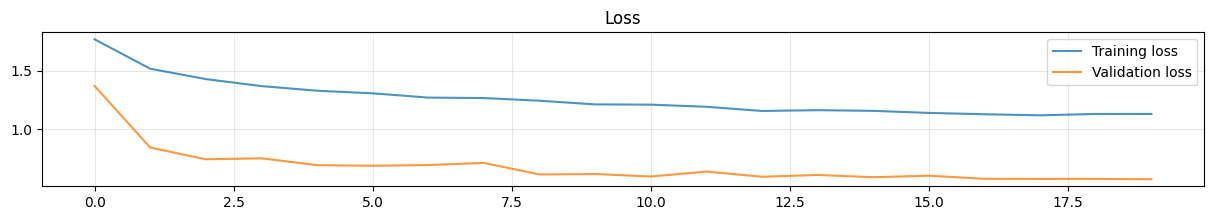

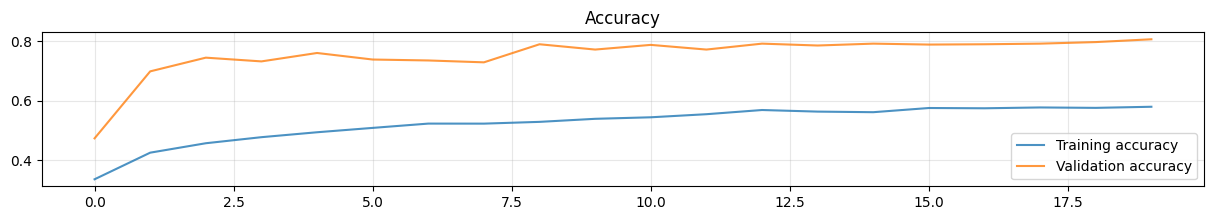

In [14]:
# Plot training and validation loss
plt.figure(figsize=(15, 2))
plt.plot(history['loss'], label='Training loss', alpha=.8)
plt.plot(history['val_loss'], label='Validation loss', alpha=.8)
plt.title('Loss')
plt.legend()
plt.grid(alpha=.3)

# Plot training and validation accuracy
plt.figure(figsize=(15, 2))
plt.plot(history['accuracy'], label='Training accuracy', alpha=.8)
plt.plot(history['val_accuracy'], label='Validation accuracy', alpha=.8)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=.3)
plt.show()


/home/teo/Desktop/LabANN/venvANNUbu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 34 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/teo/Desktop/LabANN/venvANNUbu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 30 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Predictions Shape: (2391, 8)
Accuracy score over the test set: 0.7909
Precision score over the test set: 0.7939
Recall score over the test set: 0.7909
F1 score over the test set: 0.7887


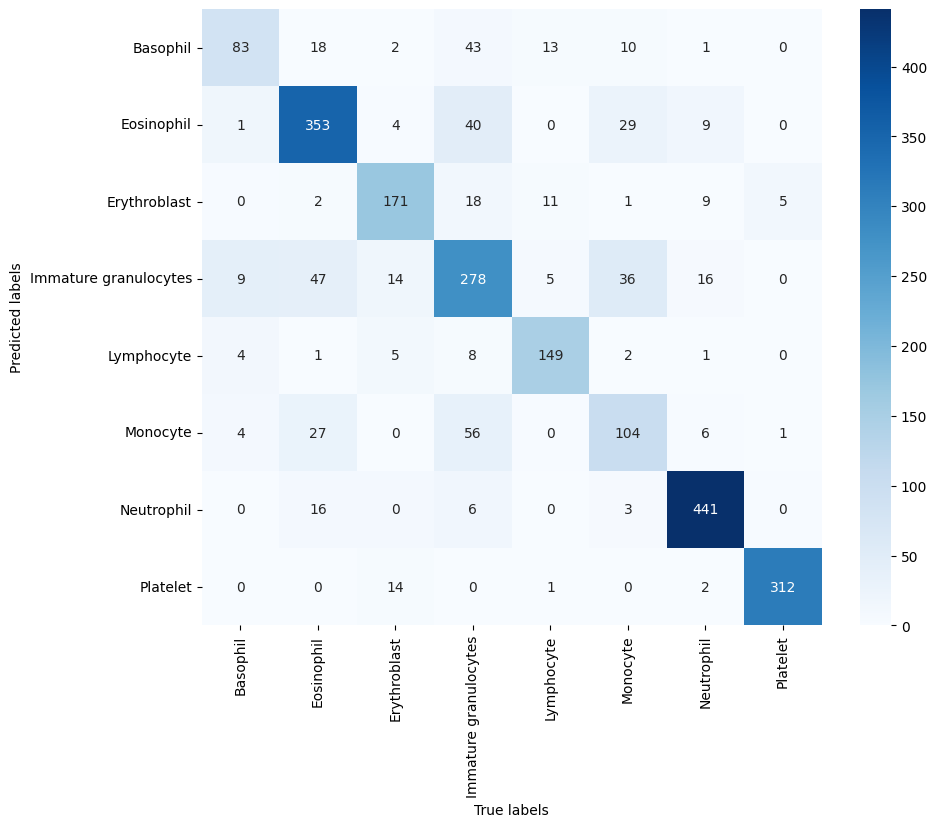

In [15]:
model = tfk.models.load_model('Submissions/rn50.keras')
# Predict labels for the entire test set
predictions = model.predict(X_test, verbose=0)

print("Predictions Shape:", predictions.shape)

# Convert predictions to class labels
pred_classes = np.argmax(predictions, axis=-1)

# Extract ground truth classes
true_classes = np.argmax(y_test, axis=-1)

accuracy = accuracy_score(true_classes, pred_classes)
print(f'Accuracy score over the test set: {round(accuracy, 4)}')

precision = precision_score(true_classes, pred_classes, average='weighted')
print(f'Precision score over the test set: {round(precision, 4)}')

recall = recall_score(true_classes, pred_classes, average='weighted')
print(f'Recall score over the test set: {round(recall, 4)}')

f1 = f1_score(true_classes, pred_classes, average='weighted')
print(f'F1 score over the test set: {round(f1, 4)}')

cm = confusion_matrix(true_classes, pred_classes)

# Combine numbers and percentages into a single string for annotation
annot = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm.T, annot=annot, fmt='', xticklabels=list(labels.values()), yticklabels=list(labels.values()), cmap='Blues')
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()